# ***VAE and IWAE for image generation***
VAE model from
*Auto-Encoding Variational Bayes (2014, D.P. Kingma et. al.)*.  
IWAE model from
*Importance Weighted Autoencoders (2015, Burda et. al.)*.

Used on the MNIST dataset 
https://www.kaggle.com/datasets/hojjatk/mnist-dataset

In [1]:
import torch
import torch.nn as nn
import torch.distributions as dist
import numpy as np
from tqdm import tqdm

torch.manual_seed(0)
np.random.seed(0)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


Using device: cpu


### ***Model Hyperparameters***


In [2]:
dataset_path = '~/datasets'
batch_size = 128

# Dimensions of the input, the hidden layer, and the latent space.
x_dim  = 784
hidden_dim = 200
latent_dim = 50

# Learning rate & epochs
lr = 1e-3
epochs = 20

### ***Load Dataset***


In [3]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

mnist_transform = transforms.Compose([
        transforms.ToTensor(),
])


train_dataset = MNIST(dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset  = MNIST(dataset_path, transform=mnist_transform, train=False, download=True)
test_labels = test_dataset.targets

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False)

### ***Define the two different model architectures***


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# Model Architecture (Matching Paper Appendix C with Xavier Init) 
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=200, latent_dim=50):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.var = nn.Linear(hidden_dim, latent_dim)
        self.activation = nn.Tanh() 
        
        # Xavier Initialization 
        nn.init.xavier_uniform_(self.linear1.weight)
        nn.init.xavier_uniform_(self.linear2.weight)
        nn.init.xavier_uniform_(self.mean.weight)
        nn.init.xavier_uniform_(self.var.weight)

    def forward(self, x):
        x = self.activation(self.linear1(x))
        x = self.activation(self.linear2(x))
        return self.mean(x), self.var(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=50, hidden_dim=200, output_dim=784):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)
        self.activation = nn.Tanh() 
        
        # Xavier Initialization
        nn.init.xavier_uniform_(self.linear1.weight)
        nn.init.xavier_uniform_(self.linear2.weight)
        nn.init.xavier_uniform_(self.out.weight)

    def forward(self, z):
        x = self.activation(self.linear1(z))
        x = self.activation(self.linear2(x))
        return torch.sigmoid(self.out(x))

class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder

    def reparameterization(self, mean, std):
        eps = torch.randn_like(std)
        z = mean + std * eps
        return z

    def forward(self, x):
        x = x.view(x.size(0), -1)
        mean, log_var = self.Encoder(x)
        std = torch.exp(0.5 * log_var)
        z = self.reparameterization(mean, std)
        theta = self.Decoder(z)
        return theta, mean, log_var, z

### ***Implementing Loss Function***


In [5]:
def get_log_weights(x, mean, log_var, model, K):
    """ Samples K times and computes log w_k = log p(x|z) + log p(z) - log q(z|x) """
    batch_size, latent_dim = mean.shape
    
    # Expand
    mean_exp = mean.unsqueeze(1).expand(batch_size, K, latent_dim)
    log_var_exp = log_var.unsqueeze(1).expand(batch_size, K, latent_dim)
    
    # Sample
    std = torch.exp(0.5 * log_var_exp)
    eps = torch.randn_like(std)
    z = mean_exp + std * eps 
    
    # Decode
    theta = model.Decoder(z.view(-1, latent_dim)).view(batch_size, K, -1)
    x_exp = x.unsqueeze(1).expand(batch_size, K, -1)
    
    # Calculate terms
    log_px_z = -F.binary_cross_entropy(theta, x_exp, reduction='none').sum(2)
    log_pz = -0.5 * torch.sum(z**2 + np.log(2*np.pi), dim=2)
    log_qz_x = -0.5 * torch.sum((z - mean_exp)**2 / torch.exp(log_var_exp) 
                                + log_var_exp + np.log(2*np.pi), dim=2)
    
    return log_px_z + log_pz - log_qz_x

def iwae_loss(log_w):
    """ Optimizes IWELBO: log(mean(exp(w))) """
    K = log_w.size(1)
    iwelbo = torch.logsumexp(log_w, dim=1) - np.log(K)
    return -torch.mean(iwelbo)

def vae_loss_k_samples(log_w):
    """ Optimizes Standard ELBO: mean(log(w)) """
    elbo = torch.mean(log_w, dim=1)
    return -torch.mean(elbo)

### ***Training The Model***


In [6]:
# Main Experiment 
K_values = [1, 5, 50]
epochs = 20 
results = {}

for K in K_values:
    for model_type in ['VAE', 'IWAE']:
        print(f"Training {model_type} with K={K}...")
        
        # Re-initialize Model (Ensure strictly fair start)
        torch.manual_seed(0)
        np.random.seed(0)
        encoder = Encoder(784, 200, 50) 
        decoder = Decoder(50, 200, 784)
        model = Model(encoder, decoder).to(device)
        optimizer = Adam(model.parameters(), lr=0.001)
        
        history = []
        for epoch in range(epochs):
            total_loss = 0
            for x, _ in train_loader:
                x = x.to(device).view(-1, 784)
                x = torch.round(x)
                optimizer.zero_grad()
                
                mean, log_var = model.Encoder(x) 
                
                log_w = get_log_weights(x, mean, log_var, model, K)
                
                if model_type == 'VAE':
                    # VAE Objective: Average of Log-Weights (Standard ELBO)
                    loss = -torch.mean(torch.mean(log_w, dim=1))
                else:
                    # IWAE Objective: Log of Average-Weights (IWELBO)
                    loss = -torch.mean(torch.logsumexp(log_w, dim=1) - np.log(K))
                
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item() * x.size(0)
            avg_bound = -total_loss / len(train_dataset)
            history.append(avg_bound)    
            print(f"  Epoch {epoch+1}: {avg_bound:.4f}")
        results[(model_type, K)] = history

print("Done!")

Training VAE with K=1...
  Epoch 1: -205.0008
  Epoch 2: -149.1619
  Epoch 3: -127.8679
  Epoch 4: -118.3954
  Epoch 5: -112.7166
  Epoch 6: -108.3112
  Epoch 7: -105.0795
  Epoch 8: -102.6822
  Epoch 9: -100.4835
  Epoch 10: -98.6117
  Epoch 11: -97.1199
  Epoch 12: -95.8987
  Epoch 13: -94.8284
  Epoch 14: -93.8207
  Epoch 15: -92.7834
  Epoch 16: -91.9415
  Epoch 17: -91.1550
  Epoch 18: -90.5296
  Epoch 19: -89.8000
  Epoch 20: -89.2796
Training IWAE with K=1...
  Epoch 1: -205.0008
  Epoch 2: -149.1619
  Epoch 3: -127.8679
  Epoch 4: -118.3954
  Epoch 5: -112.7166
  Epoch 6: -108.3112
  Epoch 7: -105.0795
  Epoch 8: -102.6822
  Epoch 9: -100.4835
  Epoch 10: -98.6117
  Epoch 11: -97.1199
  Epoch 12: -95.8987
  Epoch 13: -94.8284
  Epoch 14: -93.8207
  Epoch 15: -92.7834
  Epoch 16: -91.9415
  Epoch 17: -91.1550
  Epoch 18: -90.5296
  Epoch 19: -89.8000
  Epoch 20: -89.2796
Training VAE with K=5...
  Epoch 1: -199.7739
  Epoch 2: -141.8276
  Epoch 3: -122.8161
  Epoch 4: -113.5976


### ***Plotting the ELBO***

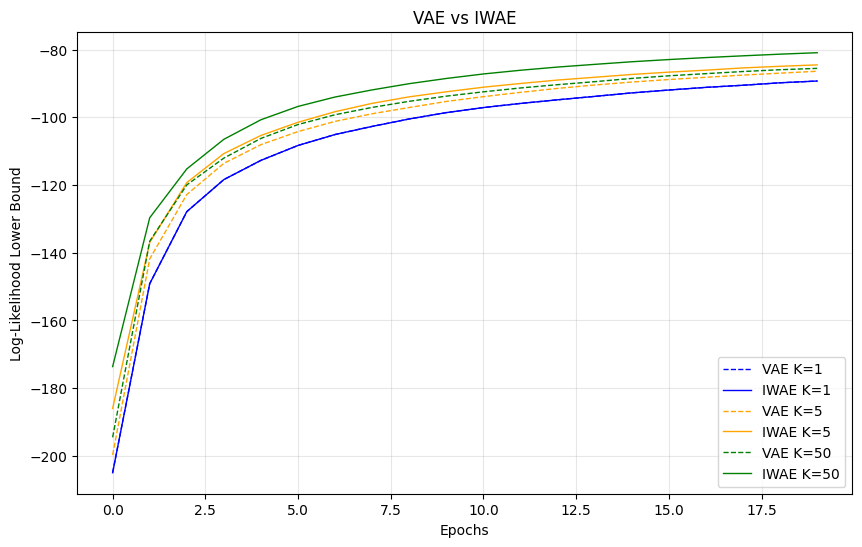

In [7]:
plt.figure(figsize=(10, 6))
colors = {1: 'blue', 5: 'orange', 50: 'green'}

for (obj_type, K), history in results.items():
    style = '--' if obj_type == 'VAE' else '-'
    
    label = f"{obj_type} K={K}"
    plt.plot(history, linestyle=style, color=colors[K], label=label, linewidth=1)

plt.xlabel("Epochs")
plt.ylabel("Log-Likelihood Lower Bound")
plt.title("VAE vs IWAE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### ***Generating MNIST samples***

100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:00<00:00, 80.74it/s]


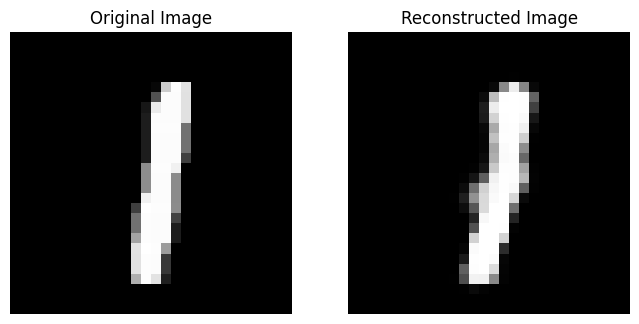

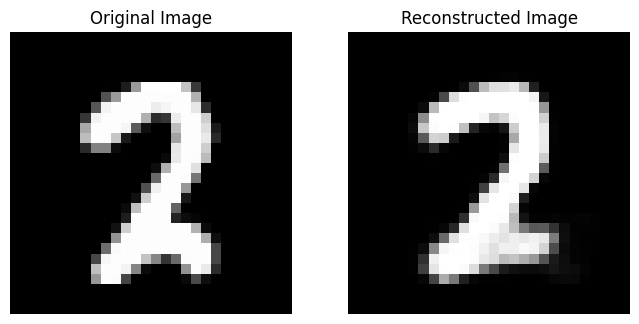

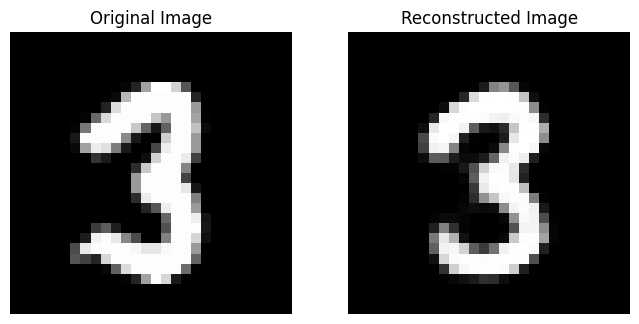

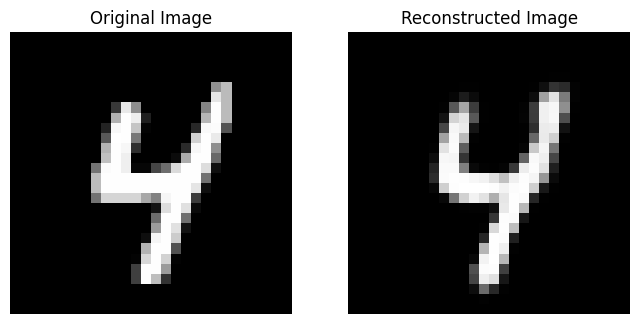

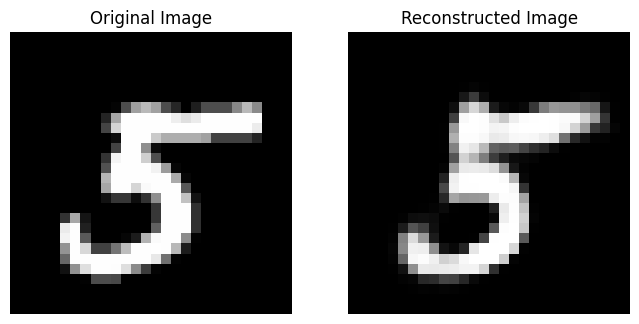

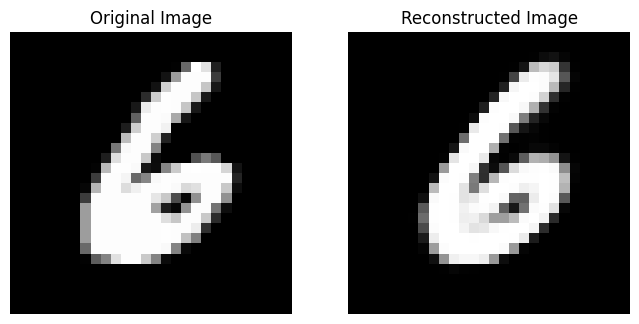

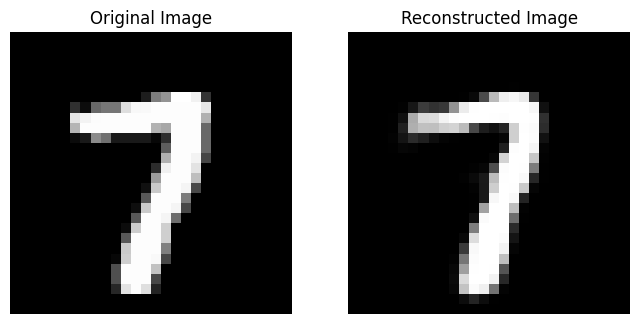

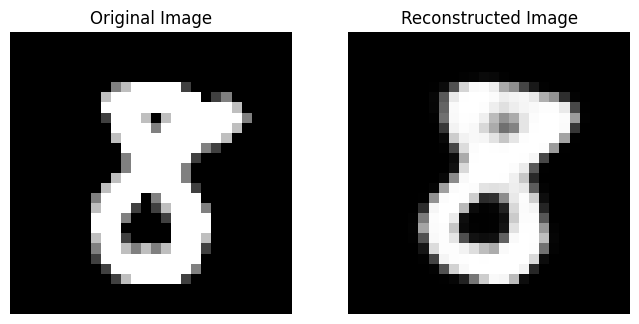

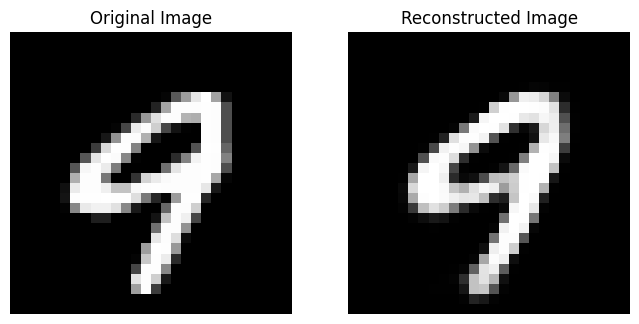

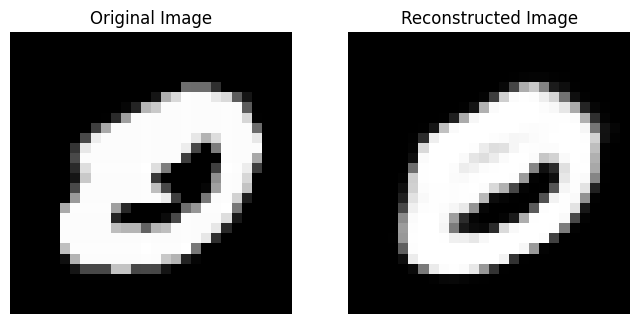

In [10]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    z_test = []
    x_test = []
    for batch_idx, (x, _) in enumerate(tqdm(test_loader)):
        x_test.append(x)
        x = x.to(device)
        x = x.view(-1, x_dim)
        x = torch.round(x)
        
        theta, mean, log_var, z = model(x)
        
        z_test.append(z.cpu().detach().numpy())

    # Save the last batch theta for visualization
    theta_batch = model.Decoder(z)

    
def compare_images(x, theta, idx):
    # Reshape inputs to (Batch, 28, 28)
    x_img = x.view(-1, 28, 28)
    theta_img = theta.view(-1, 28, 28)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Plot Original
    axes[0].imshow(x_img[idx].cpu().detach().numpy(), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Plot Reconstruction
    axes[1].imshow(theta_img[idx].cpu().detach().numpy(), cmap='gray')
    axes[1].set_title("Reconstructed Image")
    axes[1].axis('off')
    
    plt.show()

    
theta_batch = theta_batch.cpu()
compare_images(x_test[-1], theta_batch, idx=0)
compare_images(x_test[-1], theta_batch, idx=1)
compare_images(x_test[-1], theta_batch, idx=2)
compare_images(x_test[-1], theta_batch, idx=3)
compare_images(x_test[-1], theta_batch, idx=4)
compare_images(x_test[-1], theta_batch, idx=5)
compare_images(x_test[-1], theta_batch, idx=6)
compare_images(x_test[-1], theta_batch, idx=7)
compare_images(x_test[-1], theta_batch, idx=8)
compare_images(x_test[-1], theta_batch, idx=9)